# A1.2 Phase Space and Hamiltonian Flow
<hr style="height:5px;border-width:0;color:gray;background-color:gray">

## A1.2.1 Motivation: Why Phase Space?

In the Lagrangian picture, the state of a system is described by its **positions** alone; the velocities are implicitly determined by motion. But in Hamiltonian mechanics, the natural object is **phase space** — a space constructed from both positions and momenta.

Phase space is powerful because:

- It captures **all possible states** of a system in a single geometric picture.  
- It turns motion into **curves traced out** by a point moving through this space.  
- It reveals structures like fixed points, separatrices, stability, and closed orbits.  
- It allows us to understand phenomena such as **resonance**, **nonlinear oscillations**, and eventually **chaos**.  
- It gives us tools to think about **probability distributions**, **density evolution**, and **Liouville’s theorem**.  

Most importantly:

> **Phase space turns classical mechanics into geometry.**  
> You are no longer pushing symbols — you are watching trajectories evolve in a multi-dimensional space of states.

The shift from configuration space to phase space is one of the biggest conceptual upgrades in classical mechanics.

<hr style="height:5px;border-width:0;color:gray;background-color:gray">

## A1.2.2 Configuration Space vs. Phase Space

### Configuration Space 
This is the space of all possible positions:
- A particle in 1D → $Q = \mathbb{R}$  
- A particle in 3D → $Q = \mathbb{R}^3$  
- A double pendulum → $Q = S^1 \times S^1$  
- A rigid body → $Q =$ the rotation group $\mathrm{SO}(3)$  

A point in $Q$ tells you *where* the system is, but not where it is going.

### Phase Space  
Phase space is:

$$
\Gamma = \{ (q_1, \ldots, q_n; \ p_1, \ldots, p_n) \}
$$

Dimension: **$2n$**, one position and one momentum for each coordinate.

A point in $\Gamma$ contains full dynamical information: positions **and** momenta → **state = initial condition**.

<hr style="height:5px;border-width:0;color:gray;background-color:gray">

## A1.2.3 Hamiltonian Flow: Trajectories in Phase Space

Hamilton’s equations:

$$
\dot{q}_i = \frac{\partial H}{\partial p_i}, \qquad
\dot{p}_i = -\frac{\partial H}{\partial q_i},
$$

describe a **velocity field** in phase space:

$$
\mathbf{v}(q,p) = (\dot{q}_1,\ldots,\dot{q}_n,\dot{p}_1,\ldots,\dot{p}_n)
$$

The solution curves of this vector field are the **trajectories** or **orbits** in phase space. A single point moving through phase space *is* the evolution of the system.

This geometric interpretation is the key to understanding stability, periodic motion, and ultimately Liouville’s theorem and chaos.

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:14px; border-radius:4px;">

**Concept Highlight: Hamilton’s Equations Define a Vector Field**

> **Every point in phase space has a little arrow attached to it showing the system’s instantaneous direction of motion.**

Trajectories are then **integral curves** of this vector field, forming the geometric picture at the heart of Hamiltonian mechanics.

</div>

---

<div style="background-color:#e0f7fa; border-left:6px solid #006a80; padding:14px; border-radius:4px;">

**Example: Phase Space of a Harmonic Oscillator**

For the harmonic oscillator,

$$
H = \frac{p^2}{2m} + \frac12 k x^2,
$$

Hamilton’s equations give

$$
\dot{x} = \frac{p}{m}, \qquad 
\dot{p} = -kx.
$$

---

**Energy Curve (Ellipse)**  
Eliminating $t$,

$$
\frac{dp}{dx} = \frac{\dot{p}}{\dot{x}} = -\frac{km}{p}x,
$$

which integrates to the energy condition

$$
\frac{p^2}{2m} + \frac12 kx^2 = E.
$$

This is the equation of an **ellipse** in the $(x,p)$-plane.  
Every initial condition with energy $E$ lies on this ellipse.

---

**Where the Phase-Space Trajectory Comes From**

A single point in phase space, such as $(x_0, p_0)$, represents the **complete state** of the oscillator. Hamilton’s equations tell us how that state evolves in time:

- at $(x_0, p_0)$ the system has a definite velocity  

  $$
  \mathbf{v}(x_0,p_0) = 
  \left(\frac{p_0}{m},\, -k x_0\right),
  $$
  
- which determines the next point in phase space,  
- which determines the next, and so on.

Thus the **trajectory** in phase space is the curve traced out by the evolving state  

$$
(x(t), p(t)).
$$

Because the energy $E$ is constant for all time,

$$
H(x(t), p(t)) = E,
$$

the entire trajectory must lie **exactly on the energy ellipse**.

**So in this example:**

- The **energy ellipse** shows all allowed states of energy $E$.  
- The **trajectory curve** shows how the system *moves along* that ellipse as time progresses.  
- Both consist of the same set of points, but the trajectory carries *direction*, *orientation*, and *speed* information that the ellipse alone does not.

</div>

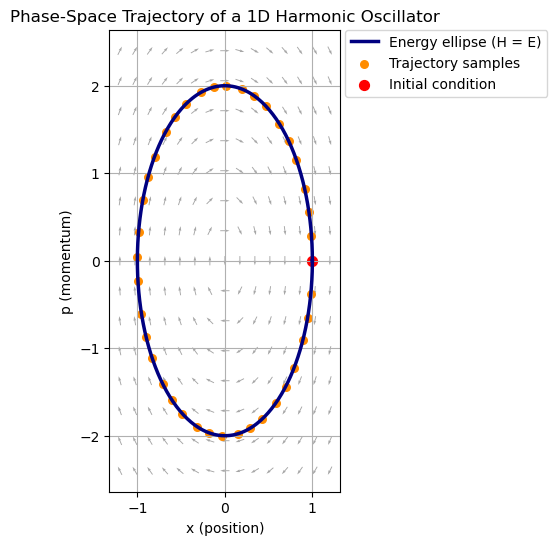

In [9]:
"""
Phase-space example: 1D harmonic oscillator

This script:
- defines the harmonic oscillator Hamiltonian
- integrates Hamilton’s equations
- plots the trajectory in phase space

"""

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.integrate import solve_ivp
except ImportError:
    raise ImportError("This script requires scipy. Please install it with `pip install scipy`.")

# -------------------------------
# Parameters and Hamiltonian
# -------------------------------
m = 1.0
k = 4.0     # choose k != m so ellipse isn't circular
omega = np.sqrt(k/m)

def H(x, p):
    return p**2/(2*m) + 0.5*k*x**2

# -------------------------------
# Hamilton's equations
# -------------------------------
def hamiltonian_system(t, z):
    x, p = z
    dxdt = p/m
    dpdt = -k*x
    return [dxdt, dpdt]

# -------------------------------
# Initial condition & integrate
# -------------------------------
x0 = 1.0
p0 = 0.0
E = H(x0, p0)

n_periods = 3
T = 2*np.pi/omega
t_max = n_periods*T
t_eval = np.linspace(0, t_max, 400)

sol = solve_ivp(
    hamiltonian_system,
    t_span=(0, t_max),
    y0=[x0, p0],
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-9
)

x_traj = sol.y[0]
p_traj = sol.y[1]

# -------------------------------
# Energy ellipse
# -------------------------------
theta = np.linspace(0, 2*np.pi, 400)
x_ellipse = np.sqrt(2*E/k)*np.cos(theta)
p_ellipse = np.sqrt(2*E*m)*np.sin(theta)

# -------------------------------
# Vector field (optional)
# -------------------------------
x_min, x_max = 1.2*x_ellipse.min(), 1.2*x_ellipse.max()
p_min, p_max = 1.2*p_ellipse.min(), 1.2*p_ellipse.max()

nx = np_points = 15
x_grid = np.linspace(x_min, x_max, nx)
p_grid = np.linspace(p_min, p_max, np_points)
X, P = np.meshgrid(x_grid, p_grid)

DX = P/m
DP = -k*X

speed = np.sqrt(DX**2 + DP**2)
speed[speed == 0] = 1.0
DXn = DX/speed
DPn = DP/speed

# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(6,6))

# vector field
ax.quiver(X, P, DXn, DPn, alpha=0.35, pivot="mid", scale=25)

# Energy ellipse (solid navy)
ax.plot(
    x_ellipse, p_ellipse,
    color="navy",
    linewidth=2.5,
    label="Energy ellipse (H = E)"
)

# Trajectory as sparse orange markers
step = 10  # subsample so markers are clearly separated
ax.scatter(
    x_traj[::step],
    p_traj[::step],
    s=30,
    color="darkorange",
    marker="o",
    label="Trajectory samples"
)

# Initial point
ax.scatter([x0], [p0], s=50, color="red", label="Initial condition")

ax.set_xlabel("x (position)")
ax.set_ylabel("p (momentum)")
ax.set_title("Phase-Space Trajectory of a 1D Harmonic Oscillator")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

# Legend outside the plot
plt.subplots_adjust(right=0.78)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0
)

plt.show()


<hr style="height:5px;border-width:0;color:gray;background-color:gray">

## A1.2.4 Fixed Points and Stability in Phase Space

Phase space is more than a place to draw curves — it is a geometric laboratory for understanding **qualitative behavior** of dynamical systems. One of its most powerful tools is the study of **fixed points** and their **stability**.

---

### What is a Fixed Point?

A fixed point (also called an *equilibrium point*) is a state where the system does **not** move:

$$
\dot{q}_i = 0, \qquad \dot{p}_i = 0.
$$

In phase space, this corresponds to a **single point** where the vector field  

$$
\mathbf{v}(q,p) = (\dot{q},\dot{p})
$$

is exactly zero — no arrow, no motion.

Examples:

- A mass at the bottom of a bowl (stable).  
- A mass balanced at the top of a hill (unstable).  
- A double-well potential has two stable points and one unstable one.

---

### Why Fixed Points Matter

Fixed points are the “anchors” of phase space.  
They determine the **local geometry** and organize the global structure of trajectories.

Near a fixed point:

- trajectories may circulate (stable center)  
- trajectories may diverge (unstable saddle)  
- separatrices may emerge (boundaries between qualitatively different motions)  
- even chaotic behavior can occur in nonlinear systems  

Understanding fixed points is the first step toward understanding stability, oscillations, bifurcations, and eventually chaos.

---

### Linearization Near a Fixed Point

To study stability, we **linearize** the equations of motion near a fixed point:

Let $(q^*, p^*)$ be a fixed point.  
Expand the Hamiltonian to quadratic order:

$$
H(q,p) \approx H(q^*, p^*) 
+ \frac12 
\begin{pmatrix}
\delta q & \delta p
\end{pmatrix}
A
\begin{pmatrix}
\delta q \\ \delta p
\end{pmatrix},
$$

where $A$ is the matrix of second derivatives (the Hessian of $H$).

Linearizing Hamilton’s equations gives:

$$
\frac{d}{dt} 
\begin{pmatrix}
\delta q \\ \delta p
\end{pmatrix}
= J A
\begin{pmatrix}
\delta q \\ \delta p
\end{pmatrix},
$$

where

$$
J =
\begin{pmatrix}
0 & 1 \\ -1 & 0
\end{pmatrix}
$$

is the **symplectic matrix**, and the eigenvalues of the matrix $JA$ determine stability.

<div style="background-color:#fff8e1; border-left:5px solid #ffc20e; padding:12px; border-radius:4px;">

**What “Symplectic” Means**

A matrix is called **symplectic** when it preserves the fundamental pairing between coordinates and their conjugate momenta, ensuring that the geometric structure of phase space—and in particular its area—is left unchanged.

</div>

---

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:14px; border-radius:4px;">

**Concept Highlight: Why Eigenvalues Determine Stability**

For a linearized system 

$$
\dot{\mathbf{z}} = M\,\mathbf{z}, \qquad M = JA,
$$  

the solution has the general form  

$$
\mathbf{z}(t) = c_1 e^{\lambda_1 t}\mathbf{v}_1 
               + c_2 e^{\lambda_2 t}\mathbf{v}_2,
$$  

where $\lambda_1$ and $\lambda_2$ are the eigenvalues of $M$.  
Thus the **sign and type** of the eigenvalues govern how nearby trajectories behave.

---

**Imaginary Eigenvalues → Stable Center**

If 

$$
\lambda = \pm i\omega,
$$ 

then

$$
e^{\lambda t} = e^{\pm i\omega t} = \cos(\omega t) \pm i \sin(\omega t).
$$

This means:

- no exponential growth or decay  
- solutions are **pure oscillations**  
- trajectories trace **closed loops** in phase space  
- nearby trajectories stay near the equilibrium forever  

This is the mathematical reason a **potential minimum** gives a **stable oscillation**.

---

**Real Eigenvalues with Opposite Signs → Saddle Point**

If  

$$
\lambda_1 = +\gamma, \qquad \lambda_2 = -\gamma,
$$ 

then 

$$
e^{\gamma t} \to \infty, \qquad e^{-\gamma t} \to 0.
$$

So:

- one direction **expands exponentially**  
- the other direction **contracts exponentially**  
- trajectories are repelled along one axis and attracted along the other  
- the equilibrium is **unstable**  
- the special trajectories that follow the stable/unstable directions form the **separatrices**

This behavior creates the characteristic **saddle structure** in phase space — the hallmark of an unstable equilibrium (e.g., a ball balanced atop a hill).

---

**Why Hamiltonian Systems Have Only These Two Cases**

For any Hamiltonian system:

- the stability matrix is $M = JA$  
- $J$ is traceless  
- $A$ is symmetric  
- therefore **the trace of $M$ is zero**

This forces the eigenvalues to come in **pairs that sum to zero**, meaning:

- **they cannot both be negative** → no stable attractors  
- **they cannot both be positive** → no repellers  
- **no spirals** → Hamiltonian systems do not have damping

Thus the only possibilities are:

- **pure imaginary pair** → stable center  
- **real opposite-sign pair** → saddle  

This is a direct consequence of **Liouville’s theorem** (volume-preserving flow) and the symplectic structure of Hamiltonian mechanics.

</div>

---

<div style="background-color:#e8f5e9; border-left:5px solid #006633; padding:12px; border-radius:4px;">

**Box Activity 1: Expand the Hamiltonian Near a Fixed Point and Identify the Hessian Matrix**

Let $(q^*, p^*)$ be a fixed point of a 1D Hamiltonian system, so that

$$
\left.\frac{\partial H}{\partial q}\right|_* = 0,
\qquad
\left.\frac{\partial H}{\partial p}\right|_* = 0.
$$

We now expand the Hamiltonian to second order in small deviations  
$\delta q = q - q^*$ and $\delta p = p - p^*$.

**Your task:** Show that the Taylor expansion of $H(q,p)$ around the fixed point can be written in compact matrix form involving the **Hessian matrix**.

---

**Steps**

**(a)** Write the second-order Taylor expansion of $H(q,p)$ around $(q^*,p^*)$.  
(Remember: all first-order terms vanish because this is a fixed point.)

**(b)** Identify the second derivatives:

- $a = \left.\frac{\partial^2 H}{\partial q^2}\right|_*$  
- $b = \left.\frac{\partial^2 H}{\partial q \partial p}\right|_*$  
- $c = \left.\frac{\partial^2 H}{\partial p^2}\right|_*$

**(c)** Assemble these into the **Hessian matrix**:

$$
A =
\begin{pmatrix}
a & b \\
b & c
\end{pmatrix}.
$$

**(d)** Show that the quadratic expansion can be written in matrix form as

$$
H(q,p) \approx H^* +
\frac12
\begin{pmatrix}
\delta q & \delta p
\end{pmatrix}
A
\begin{pmatrix}
\delta q \\[4pt] \delta p
\end{pmatrix}.
$$

This compact expression is the starting point for linearizing Hamilton’s equations.

---

<details>
<summary style="background-color:#006633; color:white; padding:8px; border-radius:4px; cursor:pointer;">
Detailed Solution
</summary>

<div style="background-color:#e8f5e9; padding:12px; border-radius:4px; margin-top:6px;">

**(a) Taylor expansion**

Because $(q^*,p^*)$ is a fixed point, all first derivatives vanish:

$$
\left.\frac{\partial H}{\partial q}\right|_*=0,
\qquad
\left.\frac{\partial H}{\partial p}\right|_*=0.
$$

Thus the Taylor expansion to second order is

$$
H(q,p) \approx 
H^* 
+ \frac12 \left.\frac{\partial^2 H}{\partial q^2}\right|_*\,\delta q^2
+ \left.\frac{\partial^2 H}{\partial q \partial p}\right|_*\,\delta q\,\delta p
+ \frac12 \left.\frac{\partial^2 H}{\partial p^2}\right|_*\,\delta p^2.
$$

---

**(b) Second derivatives**

Identify:

$$
a=\left.\frac{\partial^2 H}{\partial q^2}\right|_*,
\qquad
b=\left.\frac{\partial^2 H}{\partial q\,\partial p}\right|_*,
\qquad
c=\left.\frac{\partial^2 H}{\partial p^2}\right|_*.
$$

---

**(c) Form the Hessian**

$$
A =
\begin{pmatrix}
a & b \\
b & c
\end{pmatrix}.
$$

Note: $A$ is symmetric because mixed partials commute  
$\displaystyle \frac{\partial^2 H}{\partial q\,\partial p}
= \frac{\partial^2 H}{\partial p\,\partial q}$.

---

**(d) Matrix form of the expansion**

Write the quadratic form compactly, and write it out to show it is identical to your expansion terms in part (a):

$$
\frac12
\begin{pmatrix}
\delta q & \delta p
\end{pmatrix}
\begin{pmatrix}
a & b\\
b & c
\end{pmatrix}
\begin{pmatrix}
\delta q \\[4pt] \delta p
\end{pmatrix}
=
\frac12 a\,\delta q^2
+ b\,\delta q\,\delta p
+ \frac12 c\,\delta p^2.
$$

Thus:

$$
\boxed{
H(q,p) \approx H^* +
\frac12
\begin{pmatrix}
\delta q & \delta p
\end{pmatrix}
A
\begin{pmatrix}
\delta q \\[4pt] \delta p
\end{pmatrix}
}
$$

which is the quadratic Hamiltonian used for linear stability analysis.

</div>
</details>

</div>

---

<div style="background-color:#e8f5e9; border-left:5px solid #006633; padding:12px; border-radius:4px;">

**Box Activity 2: Linearizing Hamilton’s Equations Near a Fixed Point**

Consider a 1D Hamiltonian expanded to quadratic order around a fixed point $(q^*, p^*)$:

$$
H(q,p) \approx H^* 
+ \tfrac12\, a\, (\delta q)^2 
+ b\, (\delta q)(\delta p) 
+ \tfrac12\, c\, (\delta p)^2,
$$

where  
- $\delta q = q - q^*$  
- $\delta p = p - p^*$  
- $a = \left.\frac{\partial^2 H}{\partial q^2}\right|_*$  
- $b = \left.\frac{\partial^2 H}{\partial q\,\partial p}\right|_*$  
- $c = \left.\frac{\partial^2 H}{\partial p^2}\right|_*$  

Hamilton’s equations are:

$$
\dot{q} = \frac{\partial H}{\partial p}, 
\qquad
\dot{p} = -\frac{\partial H}{\partial q}.
$$

Your task: **derive the linearized evolution equations**

$$
\frac{d}{dt} 
\begin{pmatrix}
\delta q \\[6pt] \delta p
\end{pmatrix}
=
JA
\begin{pmatrix}
\delta q \\[6pt] \delta p
\end{pmatrix},
$$

where  

$$
J =
\begin{pmatrix}
0 & 1\\
-1 & 0
\end{pmatrix},
\qquad
A =
\begin{pmatrix}
a & b\\ 
b & c
\end{pmatrix}.
$$

---

**Steps**

**(a)** Compute  
$\displaystyle \frac{\partial H}{\partial q}, \quad \frac{\partial H}{\partial p}$  
from the quadratic Hamiltonian.

**(b)** Write the linearized Hamilton’s equations:  
$\dot{\delta q} = \frac{\partial H}{\partial p}$,  
$\dot{\delta p} = -\frac{\partial H}{\partial q}$.

**(c)** Express these as a matrix equation  
$$
\dot{\mathbf{z}} = M\,\mathbf{z},
\qquad
\mathbf{z} = 
\begin{pmatrix}
\delta q \\[3pt] \delta p
\end{pmatrix}.
$$

**(d)** Show that $M = JA$, proving that the stability is determined by the eigenvalues of $JA$.

---

<details>
<summary style="background-color:#006633; color:white; padding:8px; border-radius:4px; cursor:pointer;">
Detailed Solution
</summary>

<div style="background-color:#e8f5e9; padding:12px; border-radius:4px; margin-top:6px;">

**(a) Compute partial derivatives**

From  
$$
H \approx H^* + \tfrac12 a\,\delta q^2 + b\,\delta q\,\delta p + \tfrac12 c\,\delta p^2,
$$

we get:

$$
\frac{\partial H}{\partial q}
= a\,\delta q + b\,\delta p,
$$

$$
\frac{\partial H}{\partial p}
= b\,\delta q + c\,\delta p.
$$

---

**(b) Linearized Hamilton’s equations**

$$
\dot{\delta q} = b\,\delta q + c\,\delta p,
$$

$$
\dot{\delta p} = -a\,\delta q - b\,\delta p.
$$

---

**(c) Matrix form**

$$
\frac{d}{dt}
\begin{pmatrix}
\delta q \\[6pt] \delta p
\end{pmatrix}
=
\begin{pmatrix}
b & c\\
-a & -b
\end{pmatrix}
\begin{pmatrix}
\delta q \\[6pt] \delta p
\end{pmatrix}.
$$

Thus
$$
M =
\begin{pmatrix}
b & c\\
-a & -b
\end{pmatrix}.
$$

---

**(d) Show that $M = JA$**

$$
J A =
\begin{pmatrix}
0 & 1\\
-1 & 0
\end{pmatrix}
\begin{pmatrix}
a & b\\
b & c
\end{pmatrix}
=
\begin{pmatrix}
b & c\\
-a & -b
\end{pmatrix}
= M.
$$

Thus:

$$
\boxed{
\dot{\mathbf{z}} = J A\,\mathbf{z}
}
$$

and the eigenvalues of $JA$ determine the stability:

- imaginary → **stable center**  
- real, opposite signs → **saddle point**  

</div>
</details>

</div>


---

### Stability Types in 1 Degree of Freedom

For 1D Hamiltonian systems, fixed points fall into two universal categories:

---

#### Stable Center

Occurs when the potential has a **local minimum**:

$$
U''(q^*) > 0.
$$

Eigenvalues are **purely imaginary**.

**Phase space view:**  
- Trajectories are **closed loops** around the fixed point  
- Energy contours are nested ellipses  
- The oscillator (harmonic or not) repeatedly returns near the equilibrium

**Physical picture:**  
A mass at the bottom of a bowl.

---

#### Unstable Saddle

Occurs when the potential has a **local maximum**:

$$
U''(q^*) < 0.
$$

Eigenvalues are **real and opposite in sign**.

**Phase space view:**

- Trajectories diverge exponentially from the fixed point  
- Two special trajectories pass through the fixed point: the **separatrices**  
- They divide phase space into regions with qualitatively different behavior

**Physical picture:**  
A mass balanced at the top of a hill.

---

### Why Hamiltonian Systems Never Have Attractors

A crucial fact:

> **Hamiltonian flow preserves phase-space volume (Liouville’s theorem).**

This means:

- trajectories cannot converge to a point or orbit  
- no spirals inward or outward  
- no sinks or sources  
- no damping  
- no attractors or repellers  

Thus the only possible fixed points are:

- **centers** (neutrally stable)  
- **saddles** (unstable)  

This is a major difference between Hamiltonian systems and dissipative systems (like damped oscillators).

---

### Separatrices: The Boundaries of Motion

Unstable saddles generate **separatrices** — special trajectories that pass through the saddle and divide phase space into distinct regions:

- bounded oscillations  
- unbounded motion  
- trapped vs escaping trajectories  

Separatrices often create dramatic, easily visible structures (e.g., the classic pendulum phase portrait) and are foundational for understanding the onset of **chaos**.

---

### Geometric Summary

- A fixed point is where the motion freezes.  
- Linearization reveals whether nearby motion is oscillatory or divergent.  
- Stable centers give closed orbits.  
- Saddles give separatrices.  
- No attractors exist because phase space volume is preserved.

Phase space reveals the hidden architecture of dynamics — long before one solves the equations explicitly.


---

<div style="background-color:#e8f5e9; border-left:5px solid #006633; padding:12px; border-radius:4px;">

**Box Activity 3: Stability Analysis of a Double-Well Hamiltonian**

Consider the Hamiltonian

$$
H(x,p) = \frac{p^2}{2m} \;+\; \frac14 x^4 \;-\; \frac12 x^2.
$$

This is the **double-well potential**, often used in molecular physics, field theory, and nonlinear dynamics.

Your tasks:

---

**(a) Identify all fixed points**  
Solve for $(x^*,p^*)$ such that  

$$
\dot{x}=0, \qquad \dot{p}=0.
$$

---

**(b) Determine their stability**  
Using the formulas

$$
a = \left.\frac{\partial^2 H}{\partial x^2}\right|_*, 
\qquad
c = \left.\frac{\partial^2 H}{\partial p^2}\right|_* = \frac{1}{m},
\qquad
b = \left.\frac{\partial^2 H}{\partial x \partial p}\right|_* = 0,
$$

form the Hessian

$$
A =
\begin{pmatrix}
a & 0\\[4pt]
0 & 1/m
\end{pmatrix}
$$

and classify each fixed point using the eigenvalues of $M = JA$.

---

**(c) Sketch or plot the phase portrait**  
On the $(x,p)$ plane:

- show the fixed points  
- draw the closed orbits around stable centers  
- sketch the separatrix loops passing through the unstable saddle  
- clearly identify the “figure-eight” structure  

If you prefer, generate the plot in Python using your own script.

---

<details>
<summary style="background-color:#006633; color:white; padding:8px; border-radius:4px; cursor:pointer;">
Detailed Solution
</summary>

<div style="background-color:#e8f5e9; padding:12px; border-radius:4px; margin-top:6px;">

---

**(a) Fixed points**

Hamilton’s equations:

$$
\dot{x} = \frac{\partial H}{\partial p} = \frac{p}{m},
\qquad
\dot{p} = -\frac{\partial H}{\partial x}.
$$

Setting $\dot{x}=0$ gives $p^*=0$.

Compute  
$$
\frac{\partial H}{\partial x} = x^3 - x.
$$

Setting $\dot{p}=0$ gives:

$$
x^3 - x = 0
\quad\Rightarrow\quad
x(x^2 - 1)=0.
$$

Thus:

- $(x^*,p^*) = (0,0)$  
- $(x^*,p^*) = (+1,0)$  
- $(x^*,p^*) = (-1,0)$  

---

**(b) Stability**

Second derivatives:

$$
a = \left.\frac{\partial^2 H}{\partial x^2}\right|_*
= \left.(3x^2 - 1)\right|_*,
\qquad
c = \frac{\partial^2 H}{\partial p^2} = \frac{1}{m},
\qquad
b = 0.
$$

**At $x^*=0$**

$$
a = 3(0)^2 - 1 = -1 < 0.
$$

Thus the Hessian is

$$
A =
\begin{pmatrix}
-1 & 0\\[4pt]
0 & 1/m
\end{pmatrix}.
$$

Then

$$
M = JA =
\begin{pmatrix}
0 & 1\\
-1 & 0
\end{pmatrix}
\begin{pmatrix}
-1 & 0\\
0 & 1/m
\end{pmatrix}
=
\begin{pmatrix}
0 & 1/m\\
1 & 0
\end{pmatrix}.
$$

Eigenvalues satisfy:

$$
\lambda^2 = +\frac{1}{m}.
$$

Thus

$$
\lambda = \pm \frac{1}{\sqrt{m}}
$$

→ **real, opposite signs** → **saddle (unstable)**.

---

**At $x^* = \pm 1$**

$$
a = 3(1)^2 - 1 = 2 > 0.
$$

Thus

$$
A =
\begin{pmatrix}
2 & 0\\[4pt]
0 & 1/m
\end{pmatrix}.
$$

Then

$$
JA =
\begin{pmatrix}
0 & 1\\
-1 & 0
\end{pmatrix}
\begin{pmatrix}
2 & 0\\
0 & 1/m
\end{pmatrix}
=
\begin{pmatrix}
0 & 1/m\\
-2 & 0
\end{pmatrix}.
$$

Eigenvalues satisfy:

$$
\lambda^2 = -\frac{2}{m}.
$$

Thus:

$$
\lambda = \pm i \sqrt{\frac{2}{m}}.
$$

→ **pure imaginary** → **stable centers**.

---

**(c) Phase portrait structure**

- Two **stable centers** at $(x,p) = (\pm 1, 0)$  
- One **unstable saddle** at $(0,0)$  
- A pair of **separatrix curves** form a “figure-eight” loop around the two wells  
- Small oscillations around each stable point occur on nested closed orbits  
- Large enough energies cross the separatrix and move between wells  

This is one of the most important canonical examples of nonlinear dynamics.

</div>
</details>

</div>

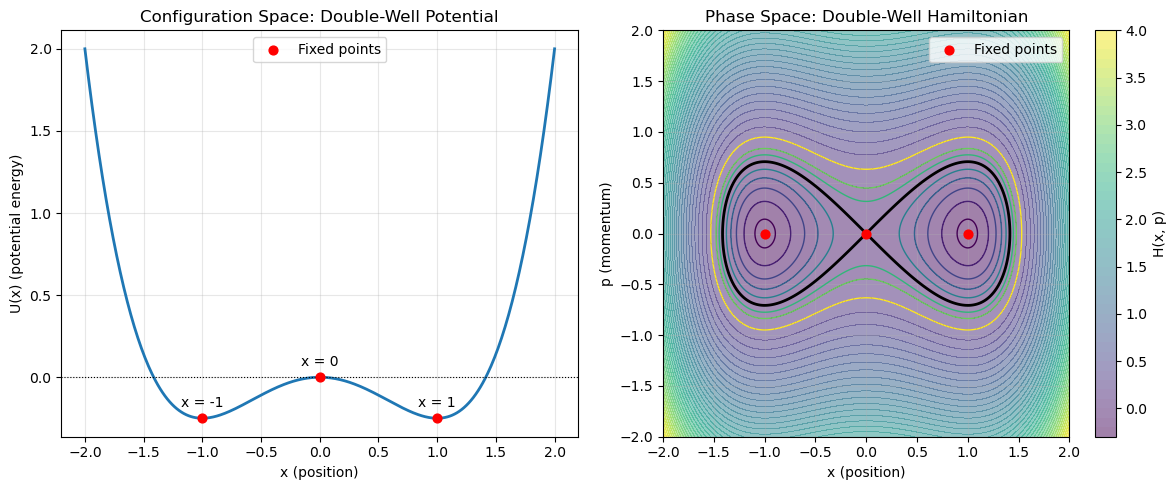

In [11]:
"""
Double-well Hamiltonian: side-by-side configuration and phase-space plots.

H(x,p) = p^2/(2m) + (1/4) x^4 - (1/2) x^2

Left:  U(x) vs x  (configuration space)
Right: Phase-space energy contours with separatrix and fixed points
"""

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Parameters and definitions
# -------------------------------
m = 1.0

def U(x):
    """Potential for the double-well."""
    return 0.25 * x**4 - 0.5 * x**2

def H(x, p):
    """Double-well Hamiltonian."""
    return p**2/(2*m) + U(x)

# -------------------------------
# x-range for configuration plot
# -------------------------------
x_conf = np.linspace(-2.0, 2.0, 400)
U_conf = U(x_conf)

# Fixed points in configuration space (x positions)
fixed_x = np.array([-1.0, 0.0, 1.0])
fixed_U = U(fixed_x)  # potential values at fixed points

# -------------------------------
# Grid for phase space
# -------------------------------
x_min, x_max = -2.0, 2.0
p_min, p_max = -2.0, 2.0

nx, np_points = 400, 400
x = np.linspace(x_min, x_max, nx)
p = np.linspace(p_min, p_max, np_points)
X, P = np.meshgrid(x, p)

H_grid = H(X, P)

# Energy at minima: H(±1, 0) = U(±1) = -1/4
# Energy at saddle: H(0, 0) = U(0) = 0 (separatrix)
E_min = U(1.0)  # should be -0.25

# Contour levels
levels = [-0.24, -0.20, -0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]

# -------------------------------
# Plotting: side-by-side
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax_conf = axes[0]
ax_phase = axes[1]

# ===== Left: U(x) vs x =====
ax_conf.plot(x_conf, U_conf, linewidth=2)
ax_conf.axhline(0.0, color="black", linewidth=0.8, linestyle=":")
ax_conf.scatter(fixed_x, fixed_U, color="red", s=40, zorder=5, label="Fixed points")

# Label fixed points
for x0, U0 in zip(fixed_x, fixed_U):
    ax_conf.text(x0, U0 + 0.05, f"x = {x0:.0f}", ha="center", va="bottom")

ax_conf.set_xlabel("x (position)")
ax_conf.set_ylabel("U(x) (potential energy)")
ax_conf.set_title("Configuration Space: Double-Well Potential")
ax_conf.grid(True, alpha=0.3)
ax_conf.legend(loc="upper center")

# ===== Right: Phase-space plot =====
# Filled contours (optional, for background structure)
cf = ax_phase.contourf(
    X, P, H_grid,
    levels=50,
    alpha=0.5
)

# Energy contours
cs = ax_phase.contour(
    X, P, H_grid,
    levels=levels,
    linewidths=1.0
)

# Highlight the separatrix H = 0
separatrix = ax_phase.contour(
    X, P, H_grid,
    levels=[0.0],
    colors="black",
    linewidths=2.0
)

# Fixed points in phase space: (x, p) = (-1,0), (0,0), (1,0)
ax_phase.scatter(fixed_x, np.zeros_like(fixed_x),
                 color="red", s=40, zorder=5, label="Fixed points")

ax_phase.set_xlabel("x (position)")
ax_phase.set_ylabel("p (momentum)")
ax_phase.set_title("Phase Space: Double-Well Hamiltonian")
ax_phase.set_xlim(x_min, x_max)
ax_phase.set_ylim(p_min, p_max)
ax_phase.set_aspect("equal", adjustable="box")
ax_phase.grid(True, alpha=0.3)
ax_phase.legend(loc="upper right")

# Colorbar for phase-space energy
cbar = fig.colorbar(cf, ax=ax_phase)
cbar.set_label("H(x, p)")

plt.tight_layout()
plt.show()


<hr style="height:5px;border-width:0;color:gray;background-color:gray">

## A1.2.5 Why Phase Space Matters

Phase space:

- reveals stability without solving differential equations  
- exposes hidden structure (invariants, symmetries, conserved quantities)  
- leads naturally to **Liouville’s theorem**  
- makes **canonical transformations** geometrically meaningful  
- provides the bridge to **chaos theory**, where trajectories stretch and fold in intricate patterns  

Hamiltonian mechanics is most powerful when students see motion **geometrically**, not just algebraically.

<hr style="height:5px;border-width:0;color:gray;background-color:gray">

## Next Section → Liouville’s Theorem

Here we show that Hamiltonian flow preserves phase-space volume — a key feature distinguishing Hamiltonian systems from dissipative ones, and an essential foundation for understanding chaos and statistical mechanics.

<hr style="height:5px;border-width:0;color:gray;background-color:gray">